# DSAC vs PPO vs MPC vs PID — Boeing 747 Pitch Control

Comparison of four controllers on a 1° step @ t=5s:
- **DSAC** (`TensorAeroSpace/dsac-b747-step-response`)
- **PPO** (`TensorAeroSpace/ppo-b747-step-response`)
- **MPC** (`TensorAeroSpace/mpc-b747-step-response`)
- **PID** (MATLAB-style auto-tuned)

All controllers are evaluated on identical conditions: same environment, same reference signal, same initial state.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from huggingface_hub import snapshot_download
import gymnasium as gym

from tensoraerospace.agent import DSAC, PPO
from tensoraerospace.agent.pid import PID
from tensoraerospace.agent.mpc import (
    MPCAgent,
    MPCWeights,
    MPCConstraints,
    MPCTrackingExtraCostConfig,
    MPCStepResponseExtraCostConfig,
)
from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = pick_device()
print(f"Device: {DEVICE}")


Device: cuda


## 2. Simulation Parameters

In [ ]:
# Simulation parameters
DT = 0.1
TN = 20.0
AMPLITUDE_DEG = 1.0
STEP_TIME_SEC = 5.0

# Time grid and reference
tp = generate_time_period(tn=TN, dt=DT)
t_sec = convert_tp_to_sec_tp(tp, dt=DT)
n_steps = len(tp)
step_time_idx = STEP_TIME_SEC  # seconds (was index)
reference_rad = np.reshape(
    unit_step(degree=AMPLITUDE_DEG, tp=tp, time_step=step_time_idx, output_rad=True),
    [1, -1]
)
reference_deg = np.rad2deg(reference_rad[0])
print(f"TN={TN}s, DT={DT}s, steps={n_steps}, step {AMPLITUDE_DEG}° @ {STEP_TIME_SEC}s")


## 3. Helper Functions (env, metrics, loaders)

In [ ]:
def make_step_reference(dt: float, tn: float, amplitude_deg: float, step_time_sec: float):
    tp = generate_time_period(tn=tn, dt=dt)
    t_sec = convert_tp_to_sec_tp(tp, dt=dt)
    step_idx = step_time_sec  # seconds (was index)
    ref_rad = unit_step(tp=tp, degree=float(amplitude_deg), time_step=step_idx, output_rad=True)
    ref_rad = np.reshape(ref_rad, (1, -1))
    return t_sec, ref_rad


def make_improved_env(
    dt: float,
    tn: float,
    amplitude_deg: float,
    step_time_sec: float,
    seed: int = 1,
    include_reference_in_obs: bool = True,
):
    t_sec, ref_rad = make_step_reference(dt, tn, amplitude_deg, step_time_sec)
    init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)
    env = ImprovedB747Env(
        initial_state=init_state,
        reference_signal=ref_rad,
        number_time_steps=ref_rad.shape[1],
        dt=dt,
        initial_elevator_deg=0.0,
        include_reference_in_obs=include_reference_in_obs,
        reward_mode="step_response",
    )
    env.reset(seed=seed)
    return env, t_sec


def make_linear_env(
    dt: float,
    tn: float,
    amplitude_deg: float,
    step_time_sec: float,
    seed: int = 1,
    use_reward: bool = False,
):
    tp = generate_time_period(tn=tn, dt=dt)
    step_idx = step_time_sec  # seconds (was index)
    ref_rad = unit_step(tp=tp, degree=float(amplitude_deg), time_step=step_idx, output_rad=True)
    ref_rad = np.reshape(ref_rad, (1, -1))
    env = gym.make(
        'LinearLongitudinalB747-v0',
        number_time_steps=ref_rad.shape[1],
        use_reward=use_reward,
        initial_state=np.array([[0.0], [0.0], [0.0], [0.0]], dtype=np.float32),
        reference_signal=ref_rad,
        state_space=["u", "w", "q", "theta"],
        output_space=["u", "w", "q", "theta"],
        tracking_states=["theta"],
        dt=dt,
    )
    env.reset(seed=seed)
    t_sec = convert_tp_to_sec_tp(tp, dt=dt)
    return env, t_sec, ref_rad


def compute_metrics(t_sec: np.ndarray, theta_deg: np.ndarray, theta_ref_deg: np.ndarray, u_deg: np.ndarray) -> dict:
    dt = float(t_sec[1] - t_sec[0])
    err = theta_ref_deg - theta_deg
    du = np.diff(u_deg, prepend=u_deg[:1]) / dt
    final_ref = theta_ref_deg[-1]
    if abs(final_ref) > 1e-6:
        tol = 0.05 * abs(final_ref)
        settled_mask = np.abs(err) <= tol
        settling_idx = len(settled_mask) - 1
        for i in range(len(settled_mask) - 1, -1, -1):
            if not settled_mask[i]:
                settling_idx = i + 1
                break
        settling_time = t_sec[min(settling_idx, len(t_sec) - 1)]
        overshoot_pct = max(0, (np.max(theta_deg) - final_ref) / final_ref * 100)
    else:
        settling_time = float('nan')
        overshoot_pct = float('nan')
    return {
        "n": int(theta_deg.size),
        "rmse_deg": float(np.sqrt(np.mean(err**2))),
        "iae_deg_s": float(np.sum(np.abs(err)) * dt),
        "ise_deg2_s": float(np.sum(err**2) * dt),
        "max_abs_err_deg": float(np.max(np.abs(err))),
        "settling_time_s": float(settling_time),
        "overshoot_pct": float(overshoot_pct),
        "u_rms_deg": float(np.sqrt(np.mean(u_deg**2))),
        "u_max_abs_deg": float(np.max(np.abs(u_deg))),
        "du_rms_deg_s": float(np.sqrt(np.mean(du**2))),
    }


def load_dsac(repo: str, device: str):
    agent = DSAC.from_pretrained(repo)
    agent.to_device(device)
    agent.eval()
    return agent


def load_mpc_agent_from_hf(repo_id: str, env, device: str, cache_dir: Path = Path("data/hf")):
    """MPC from HF + unit adapters (rad<->deg)."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    local_dir = snapshot_download(
        repo_id=repo_id,
        local_dir=cache_dir / Path(repo_id).name,
        local_dir_use_symlinks=False,
    )
    repo_dir = Path(local_dir)

    with open(repo_dir / "config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    raw_params = dict(config["policy"]["params"])
    raw_params.pop("model_class", None)
    weights_cfg = raw_params.pop("weights", None)
    constraints_cfg = raw_params.pop("constraints", None)
    tracking_cfg = raw_params.pop("tracking_config", None)
    step_cfg = raw_params.pop("step_response_config", None)

    def _arr(x):
        return None if x is None else np.asarray(x, dtype=np.float32)

    mpc_kwargs = dict(raw_params)
    mpc_kwargs["tracking_type"] = raw_params.get("tracking_type", "step_response")

    if weights_cfg:
        mpc_kwargs["weights"] = MPCWeights(
            Q_diag=_arr(weights_cfg.get("Q_diag")),
            R_diag=_arr(weights_cfg.get("R_diag")),
            S_diag=_arr(weights_cfg.get("S_diag")),
            terminal_weight=float(weights_cfg.get("terminal_weight", 1.0)),
        )
    if constraints_cfg:
        mpc_kwargs["constraints"] = MPCConstraints(
            u_min=_arr(constraints_cfg.get("u_min")),
            u_max=_arr(constraints_cfg.get("u_max")),
            du_min=_arr(constraints_cfg.get("du_min")),
            du_max=_arr(constraints_cfg.get("du_max")),
        )
    if tracking_cfg:
        mpc_kwargs["tracking_config"] = MPCTrackingExtraCostConfig(**tracking_cfg)
    if step_cfg:
        mpc_kwargs["step_response_config"] = MPCStepResponseExtraCostConfig(**step_cfg)

    for key in ["state_dim", "action_dim", "horizon", "iters", "mpc_best_check_every", "memory_capacity", "seed"]:
        if key in mpc_kwargs:
            mpc_kwargs[key] = int(mpc_kwargs[key])
    for key in ["mpc_lr", "dynamics_lr", "grad_clip_norm"]:
        if key in mpc_kwargs and mpc_kwargs[key] is not None:
            mpc_kwargs[key] = float(mpc_kwargs[key])

    mpc_kwargs["mpc_compile_dynamics"] = False
    mpc_kwargs["device"] = device
    mpc_kwargs["dtype"] = torch.float32

    def _action_to_env(u_rad: np.ndarray) -> np.ndarray:
        return np.rad2deg(np.asarray(u_rad, dtype=np.float32)).reshape(-1)

    def _action_from_env(a_deg: np.ndarray) -> np.ndarray:
        return np.deg2rad(np.asarray(a_deg, dtype=np.float32)).reshape(-1)

    agent = MPCAgent(env=env, action_to_env=_action_to_env, action_from_env=_action_from_env, **mpc_kwargs)
    state = torch.load(repo_dir / "dynamics_model.pth", map_location=device, weights_only=False)
    agent.model.load_state_dict(state)

    norms_path = repo_dir / "normalizers.npz"
    if norms_path.exists():
        data = np.load(norms_path)
        agent.x_scaler.mean = torch.as_tensor(data["x_mean"], device=device, dtype=agent.dtype)
        agent.x_scaler.std = torch.as_tensor(data["x_std"], device=device, dtype=agent.dtype)
        agent.u_scaler.mean = torch.as_tensor(data["u_mean"], device=device, dtype=agent.dtype)
        agent.u_scaler.std = torch.as_tensor(data["u_std"], device=device, dtype=agent.dtype)
        agent.y_scaler.mean = torch.as_tensor(data["y_mean"], device=device, dtype=agent.dtype)
        agent.y_scaler.std = torch.as_tensor(data["y_std"], device=device, dtype=agent.dtype)

    agent.model.eval()
    return agent


def load_ppo(repo_or_path: str, device: str):
    """Load PPO from local dir or HF repo id and move to target device."""
    agent = PPO.from_pretrained(repo_or_path)
    torch_device = torch.device(device)
    agent.device = torch_device
    agent.actor.to(torch_device)
    agent.critic.to(torch_device)
    agent.eval()
    return agent


## 4. Rollout Functions

In [9]:
def rollout_dsac(agent: DSAC, env: ImprovedB747Env, t_sec: np.ndarray):
    obs, _ = env.reset()
    theta_deg, theta_ref_deg, u_deg = [], [], []
    for _ in range(env.number_time_steps - 1):
        action = agent.select_action(obs, evaluate=True)
        u_norm = float(np.asarray(action).squeeze())
        obs, _, done, _, _ = env.step(np.array([u_norm], dtype=np.float32))
        theta = float(env.state[env._idx_theta])
        idx = int(np.clip(env.current_step, 0, env.reference_signal.shape[1]-1))
        theta_tgt = float(env.reference_signal[0, idx])
        theta_deg.append(np.rad2deg(theta))
        theta_ref_deg.append(np.rad2deg(theta_tgt))
        u_deg.append(u_norm * float(env.max_stabilizer_angle_deg))
        if done:
            break
    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(t_sec=t_sec[:len(theta_deg)], theta_deg=np.asarray(theta_deg), theta_ref_deg=np.asarray(theta_ref_deg), u_deg=np.asarray(u_deg)),
    }

def rollout_pid(pid: PID, env: ImprovedB747Env, t_sec: np.ndarray):
    obs, _ = env.reset(); pid.reset()
    theta_deg, theta_ref_deg, u_deg = [], [], []
    for step in range(env.number_time_steps - 1):
        theta_rad = float(env.state[env._idx_theta])
        idx = int(np.clip(step, 0, env.reference_signal.shape[1]-1))
        theta_ref_rad = float(env.reference_signal[0, idx])
        setpoint_deg = np.rad2deg(theta_ref_rad)
        meas_deg = np.rad2deg(theta_rad)
        control = float(pid.select_action(setpoint_deg, meas_deg))
        u_norm = float(np.clip(control / env.max_stabilizer_angle_deg, -1.0, 1.0))
        obs, _, done, _, _ = env.step(np.array([u_norm], dtype=np.float32))
        theta_deg.append(np.rad2deg(float(env.state[env._idx_theta])))
        theta_ref_deg.append(setpoint_deg)
        u_deg.append(control)
        if done:
            break
    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(t_sec=t_sec[:len(theta_deg)], theta_deg=np.asarray(theta_deg), theta_ref_deg=np.asarray(theta_ref_deg), u_deg=np.asarray(u_deg)),
    }

def rollout_ppo(agent: PPO, env: ImprovedB747Env, t_sec: np.ndarray, deterministic: bool=True):
    obs, _ = env.reset()
    theta_deg, theta_ref_deg, u_deg = [], [], []
    for _ in range(env.number_time_steps - 1):
        act_t, _, _ = agent.act(obs, deterministic=deterministic)
        obs, _, done, _, _ = env.step(act_t)
        theta_rad = float(env.state[env._idx_theta])
        idx = int(np.clip(env.current_step, 0, env.reference_signal.shape[1]-1))
        theta_ref_rad = float(env.reference_signal[0, idx])
        theta_deg.append(np.rad2deg(theta_rad))
        theta_ref_deg.append(np.rad2deg(theta_ref_rad))
        u_deg.append(float(act_t.squeeze()) * float(env.max_stabilizer_angle_deg))
        if done:
            break
    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(t_sec=t_sec[:len(theta_deg)], theta_deg=np.asarray(theta_deg), theta_ref_deg=np.asarray(theta_ref_deg), u_deg=np.asarray(u_deg)),
    }

def rollout_mpc(agent: MPCAgent, env, t_sec: np.ndarray, reference_rad: np.ndarray):
    _obs, _ = env.reset(); agent.env = env; agent.reset()
    theta_deg, theta_ref_deg, u_deg = [], [], []
    horizon = int(getattr(agent, "_mpc_horizon", 20))
    x_ref = np.zeros((horizon + 1, agent.state_dim), dtype=np.float32)
    for step in range(env.number_time_steps - 1):
        k = min(step, reference_rad.shape[1]-1)
        theta_target = float(reference_rad[0, k])
        x_ref[:] = 0.0
        x_ref[:, 3] = theta_target
        rate_idx = getattr(getattr(agent, "step_response_config", None), "rate_idx", None)
        if rate_idx is not None and 0 <= rate_idx < agent.state_dim:
            x_ref[:, rate_idx] = 0.0
        state = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)
        action = agent.select_action(state, x_ref=x_ref)
        _obs, _, done, _, _ = env.step(action)
        theta_cur_rad = float(env.unwrapped.model.xt[3])
        theta_deg.append(np.rad2deg(theta_cur_rad))
        theta_ref_deg.append(np.rad2deg(theta_target))
        u_deg.append(float(np.asarray(action).reshape(-1)[0]))
        if done:
            break
    return {
        "theta_deg": np.asarray(theta_deg),
        "theta_ref_deg": np.asarray(theta_ref_deg),
        "u_deg": np.asarray(u_deg),
        "metrics": compute_metrics(t_sec=t_sec[:len(theta_deg)], theta_deg=np.asarray(theta_deg), theta_ref_deg=np.asarray(theta_ref_deg), u_deg=np.asarray(u_deg)),
    }


## 5. Loading Agents and PID Tuning

In [ ]:
SEED = 123

# PID tuning
pid_env_tune, _, _ = make_linear_env(dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED, use_reward=False)
pid_controller = PID(env=pid_env_tune, dt=DT)
tune_result = pid_controller.tune_matlab_style(
    track_state_idx=3,
    target_settling_time=3.0,
    target_overshoot=0.0,
    n_iterations=15,
    verbose=False,
    mode="step_response",
)
print(f"PID tuned: Kp={pid_controller.kp:.4f}, Ki={pid_controller.ki:.4f}, Kd={pid_controller.kd:.4f}")


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


PID tuned: Kp=-24.6295, Ki=-0.2486, Kd=-7.8179


In [11]:
# Global SEED (fallback if the previous cell wasn't executed)
SEED = globals().get("SEED", 123)

# DSAC
print("Loading DSAC from HF…")
dsac_agent = load_dsac("TensorAeroSpace/dsac-b747-step-response", DEVICE)

# PPO
print("Loading PPO from HF…")
ppo_agent = load_ppo("TensorAeroSpace/ppo-b747-step-response", DEVICE)

# MPC
print("Loading MPC from HF…")
mpc_env_load, _, mpc_ref = make_linear_env(
    dt=DT,
    tn=TN,
    amplitude_deg=AMPLITUDE_DEG,
    step_time_sec=STEP_TIME_SEC,
    seed=SEED,
    use_reward=False,
)
mpc_agent = load_mpc_agent_from_hf("TensorAeroSpace/mpc-b747-step-response", env=mpc_env_load, device=DEVICE)


Loading DSAC from HF…


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Loading PPO from local checkpoint…


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Loading MPC from HF…


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

## 6. Running Comparisons

In [14]:
# Environments for evaluation
pid_env, t_test = make_improved_env(dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED, include_reference_in_obs=False)
dsac_env, _ = make_improved_env(dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED, include_reference_in_obs=True)
# PPO was trained without reference in obs -> use include_reference_in_obs=False
ppo_env, _ = make_improved_env(dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED, include_reference_in_obs=False)
mpc_env, t_mpc, ref_mpc = make_linear_env(dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, seed=SEED, use_reward=False)

pid_out = rollout_pid(pid=pid_controller, env=pid_env, t_sec=t_test)
dsac_out = rollout_dsac(agent=dsac_agent, env=dsac_env, t_sec=t_test)
ppo_out = rollout_ppo(agent=ppo_agent, env=ppo_env, t_sec=t_test, deterministic=True)
mpc_out = rollout_mpc(agent=mpc_agent, env=mpc_env, t_sec=t_mpc, reference_rad=ref_mpc)


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.number_time_steps to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.number_time_steps` for environment variables or `env.get_wrapper_attr('number_time_steps')` that will search the reminding wrappers.
  logger.warn(
/tmp/ipykernel_53737/1547863042.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta_cur_rad = float(env.unwrapped.model.xt[3])


## 7. Metrics Table and Winners

In [16]:
metrics_list = [
    ("RMSE (°)", "rmse_deg", "lower"),
    ("IAE (°·s)", "iae_deg_s", "lower"),
    ("ISE (°²·s)", "ise_deg2_s", "lower"),
    ("Max Error (°)", "max_abs_err_deg", "lower"),
    ("Settling Time (s)", "settling_time_s", "lower"),
    ("Overshoot (%)", "overshoot_pct", "lower"),
    ("Control RMS (°)", "u_rms_deg", "lower"),
    ("Control Max (°)", "u_max_abs_deg", "lower"),
    ("Control Rate RMS (°/s)", "du_rms_deg_s", "lower"),
]

rows = []
wins = {"DSAC":0, "PPO":0, "MPC":0, "PID":0}

for name, key, better in metrics_list:
    vals = {
        "PID": pid_out["metrics"][key],
        "DSAC": dsac_out["metrics"][key],
        "PPO": ppo_out["metrics"][key],
        "MPC": mpc_out["metrics"][key],
    }
    if better == "lower":
        best_val = min(vals.values())
        winner = [k for k,v in vals.items() if abs(v-best_val) < 1e-9][0]
    else:
        best_val = max(vals.values())
        winner = [k for k,v in vals.items() if abs(v-best_val) < 1e-9][0]
    wins[winner] += 1
    rows.append({"Metric": name, **{k: f"{v:.4f}" for k,v in vals.items()}, "Winner": winner})

LAMBDA = 0.1
composite = {}
for k,out in {"PID":pid_out, "DSAC":dsac_out, "PPO":ppo_out, "MPC":mpc_out}.items():
    composite[k] = out["metrics"]["rmse_deg"] + LAMBDA*out["metrics"]["u_rms_deg"]
best_c = min(composite.values())
best_c_w = [k for k,v in composite.items() if abs(v-best_c)<1e-9][0]
wins[best_c_w] += 1
rows.append({"Metric":"━━━━━━━━━━━━━━━━━━━━━━", "PID":"━━━━", "DSAC":"━━━━", "PPO":"━━━━", "MPC":"━━━━", "Winner":"━━━━"})
rows.append({"Metric":f"Composite (RMSE+{LAMBDA}×U_RMS)", **{k:f"{v:.4f}" for k,v in composite.items()}, "Winner": f"🏆 {best_c_w}"})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print("Wins:", wins)


                    Metric     PID    DSAC     PPO    MPC Winner
                  RMSE (°)  0.0770  0.1080  0.1149 0.1130    PID
                 IAE (°·s)  0.3018  0.4690  0.4533 0.4978    PID
                ISE (°²·s)  0.1185  0.2331  0.2643 0.2539    PID
             Max Error (°)  0.8596  1.0126  0.9905 0.9566    PID
         Settling Time (s)  5.8000  5.4000  5.5000 5.7000   DSAC
             Overshoot (%)  0.0000  0.9908  0.4905 4.6737    PID
           Control RMS (°)  2.5856  1.9975  1.5315 0.7815    MPC
           Control Max (°) 24.6544 19.8279 11.6500 7.6172    MPC
    Control Rate RMS (°/s) 29.4638 23.1413 13.6341 6.3172    MPC
    ━━━━━━━━━━━━━━━━━━━━━━    ━━━━    ━━━━    ━━━━   ━━━━   ━━━━
Composite (RMSE+0.1×U_RMS)  0.3355  0.3077  0.2681 0.1911  🏆 MPC
Wins: {'DSAC': 1, 'PPO': 0, 'MPC': 4, 'PID': 5}


## 8. Trade-off Analysis (Tracking vs Control)

Visual breakdown: X-axis — control effort / actuator load (Control RMS, lower is better), Y-axis — tracking accuracy (RMSE, lower is better).

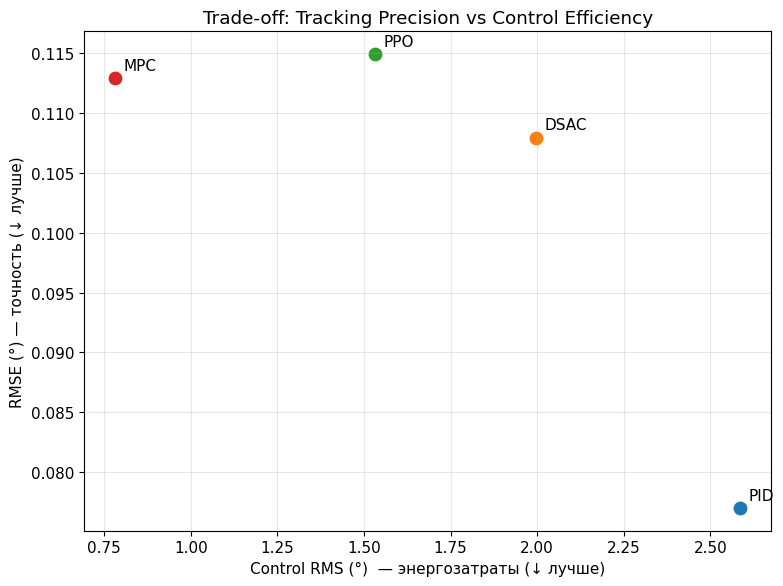

📁 Plot saved to: tradeoff_all_vs_pid.png


In [23]:
# Trade-off: RMSE vs Control RMS
trade_data = {
    "PID": (pid_out["metrics"]["u_rms_deg"], pid_out["metrics"]["rmse_deg"]),
    "DSAC": (dsac_out["metrics"]["u_rms_deg"], dsac_out["metrics"]["rmse_deg"]),
    "PPO": (ppo_out["metrics"]["u_rms_deg"], ppo_out["metrics"]["rmse_deg"]),
    "MPC": (mpc_out["metrics"]["u_rms_deg"], mpc_out["metrics"]["rmse_deg"]),
}

fig, ax = plt.subplots(figsize=(8,6))
for name, (x, y) in trade_data.items():
    ax.scatter(x, y, s=80)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6,6))

ax.set_xlabel("Control RMS (°)  — energy use (↓ better)")
ax.set_ylabel("RMSE (°) — accuracy (↓ better)")
ax.set_title("Trade-off: Tracking Precision vs Control Efficiency")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tradeoff_all_vs_pid.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Plot saved to: tradeoff_all_vs_pid.png")



## 8. Plots

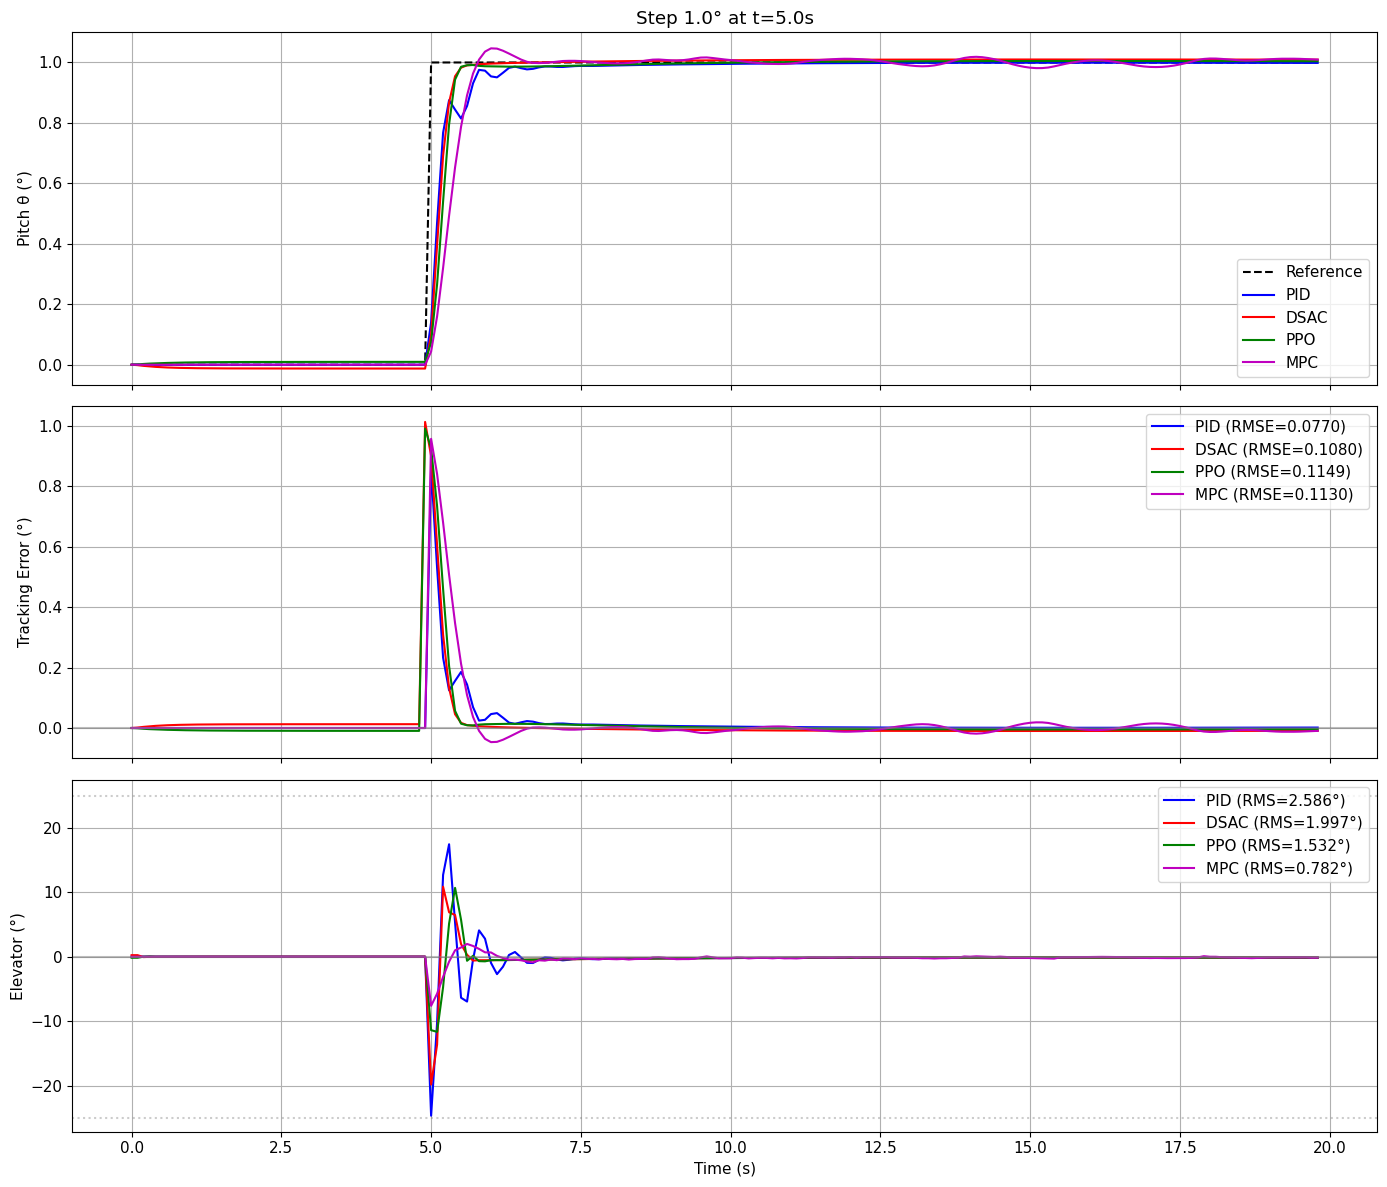


📁 Plot saved to: all_vs_pid_comparison.png


In [22]:
fig, axes = plt.subplots(3,1, figsize=(14,12), sharex=True)

min_len = min(len(pid_out["theta_deg"]), len(dsac_out["theta_deg"]), len(ppo_out["theta_deg"]), len(mpc_out["theta_deg"]))
t_plot = t_test[:min_len]

axes[0].plot(t_plot, pid_out["theta_ref_deg"][:min_len], "k--", label="Reference")
axes[0].plot(t_plot, pid_out["theta_deg"][:min_len], "b-", label="PID")
axes[0].plot(t_plot, dsac_out["theta_deg"][:min_len], "r-", label="DSAC")
axes[0].plot(t_plot, ppo_out["theta_deg"][:min_len], "g-", label="PPO")
axes[0].plot(t_plot, mpc_out["theta_deg"][:min_len], "m-", label="MPC")
axes[0].set_ylabel("Pitch θ (°)")
axes[0].legend(loc="lower right")
axes[0].set_title(f"Step {AMPLITUDE_DEG}° at t={STEP_TIME_SEC}s")

pid_err = pid_out["theta_ref_deg"][:min_len] - pid_out["theta_deg"][:min_len]
dsac_err = dsac_out["theta_ref_deg"][:min_len] - dsac_out["theta_deg"][:min_len]
ppo_err = ppo_out["theta_ref_deg"][:min_len] - ppo_out["theta_deg"][:min_len]
mpc_err = mpc_out["theta_ref_deg"][:min_len] - mpc_out["theta_deg"][:min_len]
axes[1].plot(t_plot, pid_err, "b-", label=f"PID (RMSE={pid_out['metrics']['rmse_deg']:.4f})")
axes[1].plot(t_plot, dsac_err, "r-", label=f"DSAC (RMSE={dsac_out['metrics']['rmse_deg']:.4f})")
axes[1].plot(t_plot, ppo_err, "g-", label=f"PPO (RMSE={ppo_out['metrics']['rmse_deg']:.4f})")
axes[1].plot(t_plot, mpc_err, "m-", label=f"MPC (RMSE={mpc_out['metrics']['rmse_deg']:.4f})")
axes[1].set_ylabel("Tracking Error (°)")
axes[1].legend(loc="upper right")
axes[1].axhline(y=0, color="gray", linestyle="-", alpha=0.5)

axes[2].plot(t_plot, pid_out["u_deg"][:min_len], "b-", label=f"PID (RMS={pid_out['metrics']['u_rms_deg']:.3f}°)")
axes[2].plot(t_plot, dsac_out["u_deg"][:min_len], "r-", label=f"DSAC (RMS={dsac_out['metrics']['u_rms_deg']:.3f}°)")
axes[2].plot(t_plot, ppo_out["u_deg"][:min_len], "g-", label=f"PPO (RMS={ppo_out['metrics']['u_rms_deg']:.3f}°)")
axes[2].plot(t_plot, mpc_out["u_deg"][:min_len], "m-", label=f"MPC (RMS={mpc_out['metrics']['u_rms_deg']:.3f}°)")
axes[2].set_ylabel("Elevator (°)")
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc="upper right")
axes[2].axhline(y=0, color="gray", linestyle="-", alpha=0.5)
axes[2].axhline(y=25, color="gray", linestyle=":", alpha=0.4)
axes[2].axhline(y=-25, color="gray", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("all_vs_pid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📁 Plot saved to: all_vs_pid_comparison.png")


## 9. Final Summary

In [ ]:
print("="*70)
print("🏆 Summary: DSAC vs PPO vs MPC vs PID")
print(f"Composite winner: {best_c_w} (RMSE+0.1×U_RMS={best_c:.4f})")
print("Metric score:")
for k,v in wins.items():
    print(f"  {k}: {v}")
print("="*70)


🏆 Итог: DSAC vs PPO vs MPC vs PID
Composite winner: MPC (RMSE+0.1×U_RMS=0.1911)
Счёт по метрикам:
  DSAC: 1
  PPO: 0
  MPC: 4
  PID: 5
